PROJECT TITLE:
E-Commerce Fashion Analytics

PROJECT OBJECTIVE:
The objective of this project is to analyze an e-commerce fashion dataset by cleaning the data, handling missing values and duplicates, and creating visualizations to understand customer behavior, sales performance, product categories, and pricing trends.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [3]:
#Load Dataset

df=pd.read_csv(r"C:\Users\Afeefa PC\Downloads\Snitch_Fashion_Sales_Uncleaned.csv")


ABOUT THE DATASET

In [4]:
df.head(10)

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,NaN,842.00,0.60,0.00,2025-02-27,Delhi,B2C,2137.45
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1.0,NaN,NaN,0.00,2025-07-15,Ahmedabad,NaN,1588.15
2,1002,Sarah Snyder,Jackets,Puffer Coat,1.0,637.82,NaN,0.00,02-01-2025,Mumbai,B2B,-158.03
3,1003,Jay Briggs,Shoes,Loafers,2.0,2962.27,NaN,0.00,18-06-2025,bengaluru,B2B,2296.50
4,1004,Maria Blake,Accessories,Belts,1.0,2881.07,0.27,2103.18,NaN,hyderbad,NaN,63.66
5,1005,Samuel Miller,T-Shirts,Crop Top,NaN,NaN,NaN,0.00,2023-12-05,Mumbai,B2B,1477.73
6,1006,John Mclean,Jeans,Boyfriend Jeans,1.0,2060.85,NaN,0.00,2024-04-02,Ahmedabad,B2B,198.36
7,1007,Dr. Kathryn Bass PhD,Dresses,Casual Midi,NaN,3669.56,NaN,0.00,NaN,Bangalore,B2C,2490.01
8,1008,Marie Fisher,Accessories,Sunglasses,NaN,NaN,NaN,0.00,NaN,Ahmedabad,B2C,-886.80
9,1009,Dale Perry,T-Shirts,Oversized T-shirt,5.0,NaN,NaN,0.00,2025-07-20,Bangalore,B2B,-972.73


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Customer_Name     2500 non-null   str    
 2   Product_Category  2500 non-null   str    
 3   Product_Name      2500 non-null   str    
 4   Units_Sold        1194 non-null   float64
 5   Unit_Price        1290 non-null   float64
 6   Discount_%        849 non-null    float64
 7   Sales_Amount      2500 non-null   float64
 8   Order_Date        1894 non-null   str    
 9   City              2500 non-null   str    
 10  Segment           1679 non-null   str    
 11  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), str(6)
memory usage: 234.5 KB


In [6]:
df.describe()

,Order_ID,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Profit
count,2500.000000,1194.000000,1290.000000,849.000000,2500.000000,2500.000000
mean,2193.060000,1.940536,2691.715527,0.646466,126.756252,981.569032
std,748.063846,2.625680,1320.448967,0.380331,1464.944525,1159.159244
min,1000.000000,-2.000000,400.210000,0.000000,-7518.330000,-992.610000
25%,1543.750000,0.000000,1526.195000,0.300000,0.000000,-19.670000
50%,2182.500000,2.000000,2685.985000,0.650000,0.000000,947.885000
75%,2842.250000,4.000000,3824.347500,0.980000,0.000000,1993.515000
max,3499.000000,6.000000,4998.910000,1.300000,29180.680000,2997.110000


DATA CLEANING

From the data, I noticed several cleaning issues:

✅ Missing values in Units_Sold, Unit_Price, Discount_%, Order_Date, and Segment.
✅ Duplicate Order_ID values (for example, 1002, 1003, 1031, etc.).
✅ Inconsistent city names such as Hyd, Hyderabad, hyderbad, bengaluru, and Bangalore.
✅ Invalid values like negative Units_Sold, and incorrect Sales_Amount values.

In [7]:
#check missing values

df.isnull().sum()

Order_ID               0
Customer_Name          0
Product_Category       0
Product_Name           0
Units_Sold          1306
Unit_Price          1210
Discount_%          1651
Sales_Amount           0
Order_Date           606
City                   0
Segment              821
Profit                 0
dtype: int64

In [8]:
#fill missing numerical columns

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [9]:
# fill missing categorical columns

cat_cols = df.select_dtypes(include=['str']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
df.isnull().sum()

Order_ID            0
Customer_Name       0
Product_Category    0
Product_Name        0
Units_Sold          0
Unit_Price          0
Discount_%          0
Sales_Amount        0
Order_Date          0
City                0
Segment             0
Profit              0
dtype: int64

In [11]:
# check data type

df.dtypes

Order_ID              int64
Customer_Name           str
Product_Category        str
Product_Name            str
Units_Sold          float64
Unit_Price          float64
Discount_%          float64
Sales_Amount        float64
Order_Date              str
City                    str
Segment                 str
Profit              float64
dtype: object

In [12]:
# convert the datatype of order date

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    dayfirst=True,
    errors="coerce"
).fillna(
    pd.to_datetime(df["Order_Date"], dayfirst=True, errors="coerce").mode()[0]
)


C:\Users\Afeefa PC\AppData\Local\Temp\ipykernel_17924\1119972323.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["Order_Date"] = pd.to_datetime(
C:\Users\Afeefa PC\AppData\Local\Temp\ipykernel_17924\1119972323.py:8: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  pd.to_datetime(df["Order_Date"], dayfirst=True, errors="coerce").mode()[0]


In [13]:
df.dtypes

Order_ID                     int64
Customer_Name                  str
Product_Category               str
Product_Name                   str
Units_Sold                 float64
Unit_Price                 float64
Discount_%                 float64
Sales_Amount               float64
Order_Date          datetime64[us]
City                           str
Segment                        str
Profit                     float64
dtype: object

In [14]:
#remove duplicate rows

df.drop_duplicates(inplace=True)

In [15]:
# remove extra spaces
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include="str").columns:
    df[col] = df[col].str.strip()


In [16]:
# standerdize city names

df["City"] = df["City"].replace({
    "Hyd":"Hyderabad",
    "hyderbad":"Hyderabad",
    "HYDERBAD":"Hyderabad",
    "bengaluru":"Bangalore"
})

In [17]:
# remove outliers

numerical = ["Units_Sold","Unit_Price","Sales_Amount","Profit"]

for col in numerical:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

In [18]:
# Remove Negative Units Sold

df.loc[df["Units_Sold"] < 0, "Units_Sold"] = np.nan

df["Units_Sold"] = df["Units_Sold"].fillna(
    df["Units_Sold"].median()
)

In [19]:
#final check

df.info()

<class 'pandas.DataFrame'>
Index: 807 entries, 3 to 2490
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          807 non-null    int64         
 1   Customer_Name     807 non-null    str           
 2   Product_Category  807 non-null    str           
 3   Product_Name      807 non-null    str           
 4   Units_Sold        807 non-null    float64       
 5   Unit_Price        807 non-null    float64       
 6   Discount_%        807 non-null    float64       
 7   Sales_Amount      807 non-null    float64       
 8   Order_Date        807 non-null    datetime64[us]
 9   City              807 non-null    str           
 10  Segment           807 non-null    str           
 11  Profit            807 non-null    float64       
dtypes: datetime64[us](1), float64(5), int64(1), str(5)
memory usage: 82.0 KB


In [20]:
print(df.isnull().sum())


Order_ID            0
Customer_Name       0
Product_Category    0
Product_Name        0
Units_Sold          0
Unit_Price          0
Discount_%          0
Sales_Amount        0
Order_Date          0
City                0
Segment             0
Profit              0
dtype: int64


In [21]:
print(df.duplicated().sum())


0


In [22]:
print(df.shape)

(807, 12)


In [23]:
# Recalculate Sales Amount

df["Sales_Amount"] = (
    df["Units_Sold"] *
    df["Unit_Price"] *
    (1 - df["Discount_%"])
)

In [24]:
# Save Clean Dataset

df.to_csv("Snitch_Fashion_Sales_Cleaned.csv", index=False)

CONCLUSION

The `Snitch_Fashion_Sales_Uncleaned.csv` dataset was successfully cleaned using Python and Pandas. The cleaning process included checking the dataset structure, handling missing values, removing duplicate records, cleaning extra spaces, correcting inconsistent city names, converting the `Order_Date` column into the proper date format, and handling invalid negative values in the `Units_Sold` column. Outliers were also identified and treated using the IQR method.

After the cleaning process, the dataset became more consistent, accurate, and suitable for further analysis and visualization. The cleaned dataset can now be used for sales analysis, customer analysis, product performance analysis, and business insights.




DATA VISUALISATION

Data visualization is an important part of the Snitch Fashion Sales Analysis because it helps convert the cleaned sales data into meaningful graphical information. After completing the data cleaning process, the cleaned dataset is used to identify sales patterns, product performance, customer segments, geographical trends, and profitability.
The main objective of these visualizations is to make the data easier to understand and to identify useful business insights. These insights can help in understanding which products and categories perform well, which cities generate higher sales, how sales and profit change over time, and which customer segments contribute more to the business.

1. Sales by Product Category

Chart: Bar chart

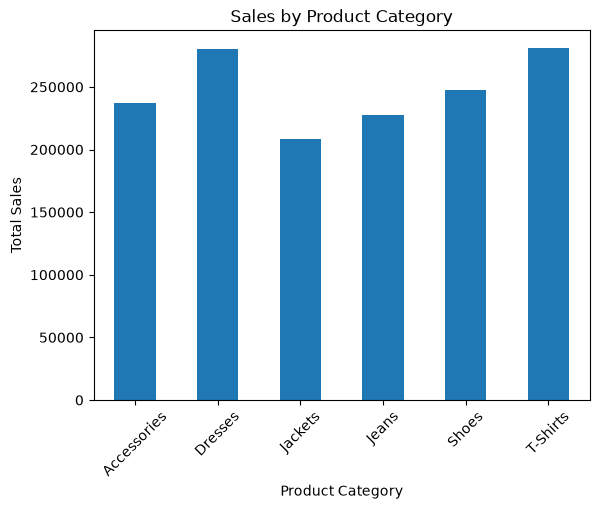

In [25]:
#Bar chart

import matplotlib.pyplot as plt
import pandas as pd

sales_category = df.groupby("Product_Category")["Sales_Amount"].sum()

sales_category.plot(kind="bar")

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

2.Monthly Sales Trend

chart:Line chart

A line chart is a good choice for showing the sales trend over time.

Here First we want to  create a month column:

In [26]:
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)

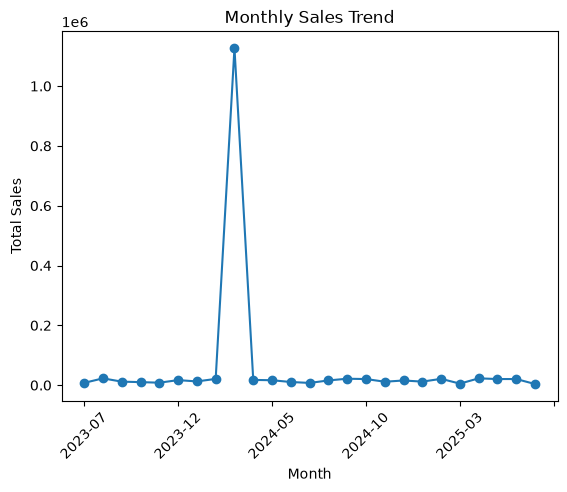

In [27]:
#Line chart

monthly_sales = df.groupby("Month")["Sales_Amount"].sum()

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

3. Top 10 Products by Sales — Horizontal Bar Chart

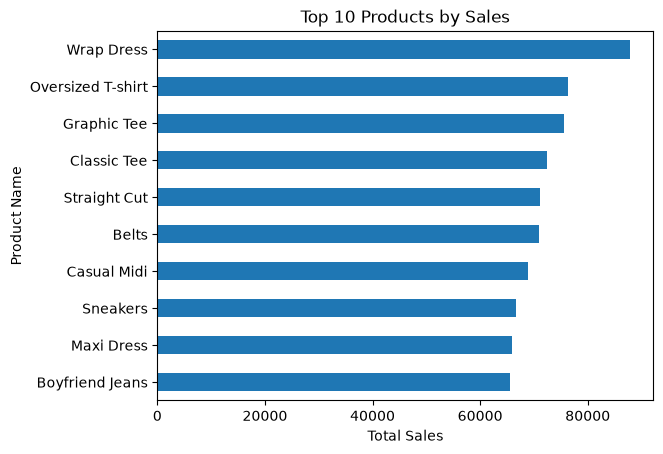

In [28]:
# Horizontal barchart

top_products = (
    df.groupby("Product_Name")["Sales_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()

4. Sales by Customer Segment — Pie Chart

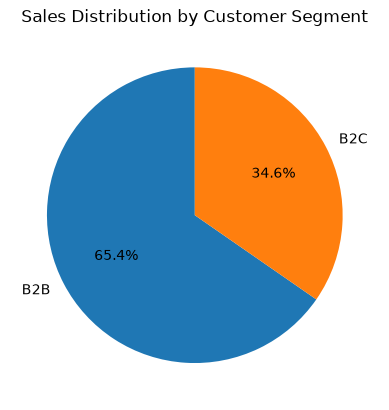

In [30]:
# pie chart

segment_sales = df.groupby("Segment")["Sales_Amount"].sum()

segment_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Distribution by Customer Segment")
plt.ylabel("")
plt.show()

5. Unit Price vs Sales Amount — Scatter Plot

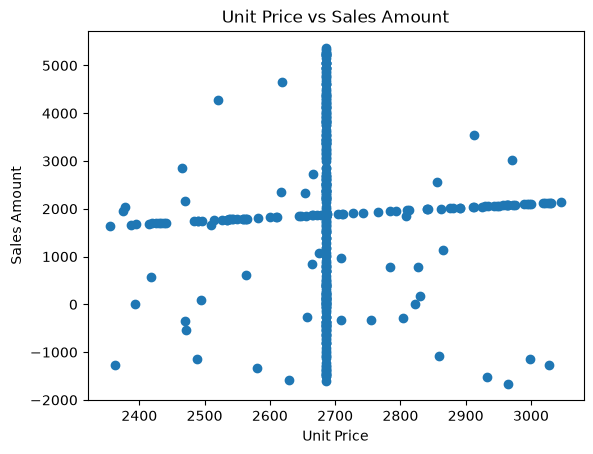

In [31]:
#scatter plot

plt.scatter(
    df["Unit_Price"],
    df["Sales_Amount"]
)

plt.title("Unit Price vs Sales Amount")
plt.xlabel("Unit Price")
plt.ylabel("Sales Amount")
plt.show()

6. Distribution of Sales Amount — Histogram

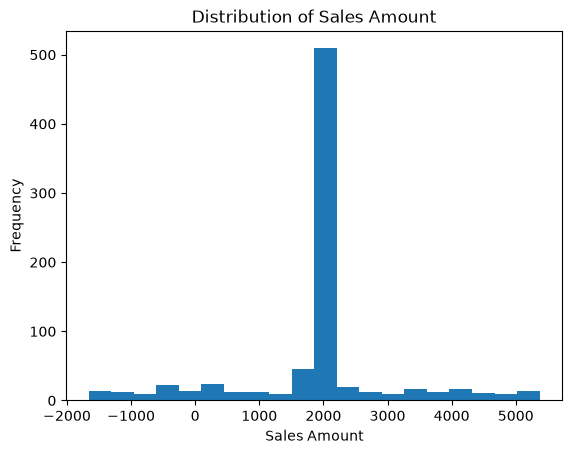

In [32]:
# Histogram

plt.hist(
    df["Sales_Amount"],
    bins=20
)

plt.title("Distribution of Sales Amount")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.show()

7. Profit Distribution — Box Plot

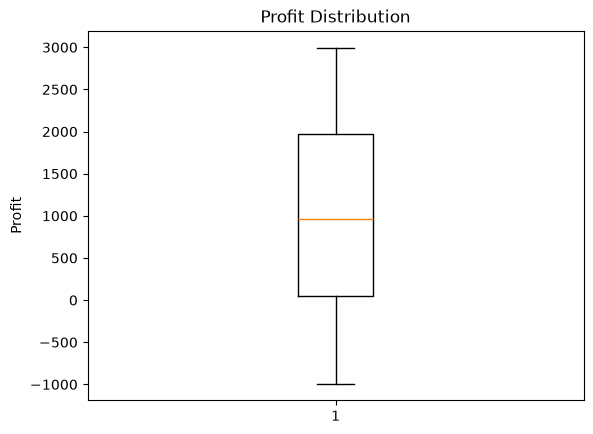

In [33]:
#Box plot

plt.boxplot(df["Profit"].dropna())

plt.title("Profit Distribution")
plt.ylabel("Profit")
plt.show()

8. Monthly Sales — Area Chart

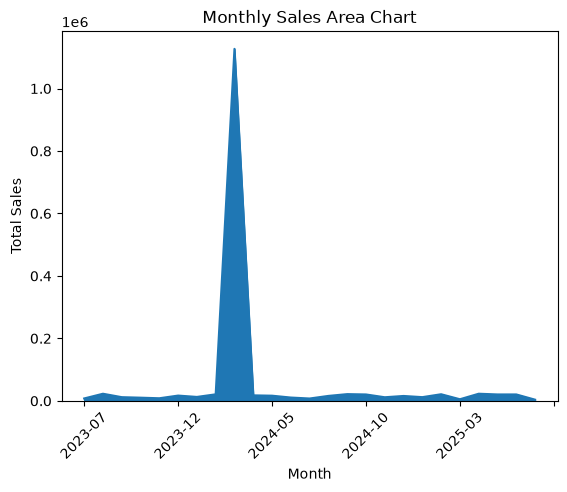

In [35]:
#Area chart

monthly_sales = df.groupby("Month")["Sales_Amount"].sum()

monthly_sales.plot(kind="area")

plt.title("Monthly Sales Area Chart")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

9. Category vs Segment Sales — Stacked Bar Chart

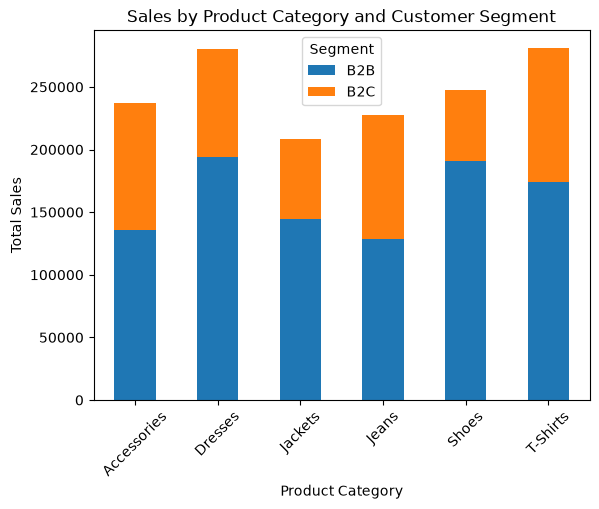

In [36]:
# stacked bar chart

category_segment = pd.pivot_table(
    df,
    values="Sales_Amount",
    index="Product_Category",
    columns="Segment",
    aggfunc="sum",
    fill_value=0
)

category_segment.plot(kind="bar", stacked=True)

plt.title("Sales by Product Category and Customer Segment")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title="Segment")
plt.show()

10. Category vs Segment Sales — Heatmap

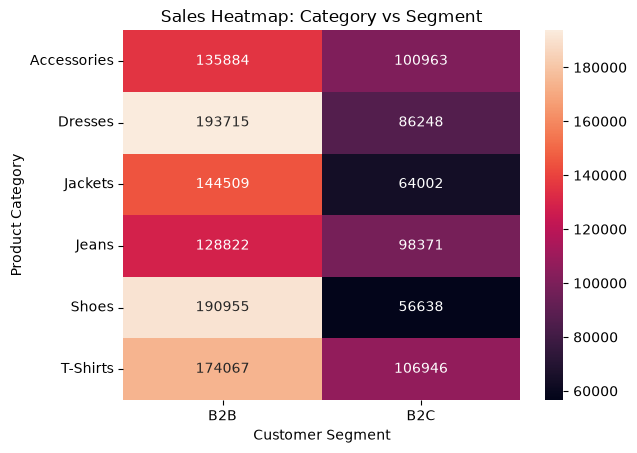

In [37]:
# Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

category_segment = pd.pivot_table(
    df,
    values="Sales_Amount",
    index="Product_Category",
    columns="Segment",
    aggfunc="sum",
    fill_value=0
)

sns.heatmap(
    category_segment,
    annot=True,
    fmt=".0f"
)

plt.title("Sales Heatmap: Category vs Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Product Category")
plt.show()

CONCLUSION OF DATA VISUALISATION

The visualization of the cleaned Snitch Fashion Sales dataset provided a clear graphical understanding of the company's sales performance, product performance, customer segments, and profitability. Different types of visualizations were used to analyze the data from multiple perspectives.
The bar charts helped compare sales and performance across product categories and products, making it easier to identify high- and low-performing products. The line chart showed the changes in sales over time and helped identify variations in monthly sales. The pie chart provided an understanding of the contribution of different customer segments to overall sales.The scatter plot was used to examine the relationship between unit price and sales amount. The points were widely distributed, indicating that there was no clear linear relationship between the two variables. The histogram helped understand the distribution of sales amounts, while the box plot showed the spread of profit and highlighted the presence of both positive and negative profit values.The area chart provided another view of sales trends over time, while the stacked bar chart helped compare sales across product categories and customer segments simultaneously. The heatmap provided a visual comparison of sales intensity between product categories and customer segments.

INSIGHTS FROM THE ANALYSIS
1. Sales performance varies across product categories

The Sales by Product Category visualization shows that sales are not equally distributed among all product categories. Some categories contribute more significantly to total sales than others. This indicates that customer demand is stronger for certain types of fashion products.

Business insight: The company can focus inventory, promotions, and marketing efforts on high-performing categories while reviewing the performance of weaker categories.

2. Product performance is different across individual products

The Top 10 Products by Sales visualization helps identify products that contribute more to overall revenue. This shows that a small number of products can play an important role in sales performance.

Business insight: High-performing products should be kept sufficiently stocked, while low-performing products may require promotional offers or changes in pricing and marketing.

3. Sales show significant variation over time

The Monthly Sales Trend showed relatively lower sales during most months but a very large spike around early 2024, reaching approximately 1.1 million. Sales then returned to much lower levels. This is an important unusual pattern that should be investigated rather than ignored.

Business insight: The spike could represent a major sales event, unusual transaction, or a remaining data-quality issue. Understanding its cause is important before making long-term business decisions.

4. Customer segments contribute differently to sales

The Sales Distribution by Customer Segment visualization compares B2B and B2C customers. The contribution of these segments is not identical.

Business insight: Understanding which segment generates more revenue can help Snitch Fashion develop different marketing and sales strategies for business customers and individual consumers.

5. Unit price does not show a clear linear relationship with sales

The Unit Price vs Sales Amount scatter plot shows that the observations are widely scattered. There is a large concentration of records around a unit price of approximately 2,700, but the sales amounts vary considerably.

Business insight: Higher product prices do not automatically result in higher sales. Other factors such as product popularity, category, customer segment, and demand may influence sales.

6. Sales amounts have considerable variation

The Sales Amount Histogram shows how sales values are distributed. The presence of widely varying sales values indicates that transactions do not all contribute equally to revenue.

Business insight: The company can investigate high-value transactions separately and understand what products or customer segments are responsible for them.

7. Profitability varies considerably

The Profit Distribution Box Plot shows that profit ranges from approximately -1,000 to 3,000, with the median around 950.

The presence of negative profit values indicates that some transactions resulted in losses.

Business insight: Loss-making transactions should be investigated to understand whether they are caused by discounts, product costs, returns, pricing issues, or other factors.

8. Sales trends can be monitored over time

The Area Chart provides another view of the sales pattern across months. It makes changes in sales volume easier to observe and highlights periods of higher and lower activity.

Business insight: Monthly trends can help the company plan inventory, promotions, staffing, and marketing campaigns according to periods of high or low demand.

9. Customer segment performance differs across product categories

The Stacked Bar Chart combines product categories and customer segments. It helps show how B2B and B2C customers contribute to sales within different categories.

Business insight: A product category that performs well with B2C customers may not perform equally well with B2B customers. This can help the company create more targeted sales strategies.

10. Some category-segment combinations perform better than others

The Heatmap provides a quick comparison of sales across product categories and customer segments. Higher-value combinations are visually easier to identify.

Business insight: Snitch Fashion can use these patterns to focus marketing and inventory decisions on the category-segment combinations that generate stronger sales.

 Overall Project Insights

From the overall analysis, the following major insights can be highlighted:

Product categories and individual products contribute differently to total sales.
Sales fluctuate considerably over time, including one unusually large sales spike around early 2024.
B2B and B2C segments have different contributions to sales.
Unit price alone does not clearly determine sales performance.
Profitability varies significantly, with both profitable and loss-making transactions.
Some transactions show negative sales or profit values, which should be carefully interpreted during business analysis. The source data contains examples of negative sales amounts and negative profits.
The analysis demonstrates that data visualization makes patterns and unusual values easier to identify.
The insights can support decisions regarding inventory management, pricing, promotions, product selection, and customer targeting.

    
 Final Insight

The analysis shows that Snitch Fashion's sales performance is influenced by multiple factors, including product category, individual product, customer segment, time, and pricing. While some products and categories contribute strongly to sales, profitability is not uniform across all transactions. The visualizations also revealed unusual patterns, such as a major sales spike and negative sales/profit values, highlighting the importance of continuous data-quality checks. Overall, the analysis provides useful information for improving product planning, marketing strategies, inventory management, and data-driven business decision-making.